## Домашка 4

#### *«Вы видите, но не наблюдаете.» — Шерлок*

Эта домашка про мониторинг метрик и детекцию аномалий. За неё можно получить максимум 12 баллов. На решение отводится **14 календарных дней** с момента выдачи. Обратите внимание, что **дедлайны на курсе сразу жёсткие**, а значит отправка решений после них запрещена.
Задание выполняется самостоятельно, списывания не допускаются. При обнаружении одинаковых работ балл за задание анулируется у всех студентов, вне зависимости от того, кто у кого списал.

#### **Как сдать домашку?**
1. Создайте закрытый репозиторий в личном гитхаб аккаунте для нашего предмета.
2. Пригласите в него своего ассистента — распределение по ассистентам и их гитхаб юзернеймы находятся в [ведомости](https://docs.google.com/spreadsheets/d/13lHNf6xU6tZhqzVMAb8sV3RgyyDatepwo7FJ6FhZ0vY/edit?usp=sharing) на листочке нашей дисциплины. Это можно сделать в настройках через раздел Collaborators and teams, уровень доступа ассистента должен быть Write.
3. Скачайте этот ноутбук и решите задания (локально или в Google Colab).
4. В репозитории предмета создайте ветку с номером ДЗ (например hw_4). В эту ветку запушьте .ipynb-файл с решением. Создайте pull request и добавьте в него ассистента как Reviewer. В этот же PR можете пушить сколько угодно изменений, будем смотреть на последнюю версию до наступления дедлайна.
5. В процессе решения вы будете получать ответы на список вопросов, собранный в Яндекс-Формах. Впишите в него ответы.
6. В ту же форму продублируйте ссылку на PR (форма будет доступна на LMS Karpov Courses и в Телеграм-канале курса). Вопросы в Формах с автопроверкой, однако сданный тест, к которому не была приложена ссылка на ноутбук с расчетом ответов, получает 0 баллов.

Пункты 1-2 проделываются один раз. Если вы прошли эти шаги при сдаче других домашек, повторять их не нужно, начинайте сразу с пункта 3.

**Внимание**: Если вы работаете в Google Colab, также скачивайте .ipynb файл и публикуйте его в репозитории. Ссылки на Colab к сдаче не принимаются.


Все датасеты, с которыми предлагается работать в домашних заданиях, взяты из открытых источников или сгенерированы. Любые паттерны, найденные вне заданной канвы решения, являются случайными и не несут в себе смысла или инсайта.

[Данные](https://github.com/brezhnevaan/hse_product_metrics_course/releases/download/datasets_for_hw/hw_4_data.zip)

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.stats import t
from statsmodels.tsa.seasonal import STL
import math

### Warm up

#### 1. Сопоставьте метод детекции аномалий с контекстом применения — 2 балла

a) Онлайн-мониторинг   
b) Батч-анализ по историческим данным  

1. Правило 3σ.
2. Generalized ESD
3. Grubbs test
4. CUMSUM
5. EWMA
6. STL-разложение + Generalized ESD

Ответ:

1 - a

2 - b

3 - b

4 - a

5 - a

6 - b

### Case Study. Система мониторинга метрик для Ecom-приложения 🥪

**Легенда**  
Вы работаете продуктовым аналитиком в ecom-приложении доставки FMCG-товаров. Компания — развивающийся стартап, в котором еще не выстроена система мониторинга метрик.   

Вам поручили провести исследование подходов к детекции аномалий на исторических данных и выбрать методологии, которые будет применять ваша компания для онлайн-мониторинга и ретроспективного анализа.

In [2]:
df = pd.read_csv('hw_4_fmcg.csv')

In [3]:
df['date'] = pd.to_datetime(df['date'])

In [4]:
df.head()

,date,items_sold,gmv,avg_item_price
0,2023-01-01,2907,14944.41,5.140836
1,2023-01-02,3030,16065.13,5.302023
2,2023-01-03,3070,17170.30,5.592932
3,2023-01-04,2708,14367.19,5.305462
4,2023-01-05,3177,16918.53,5.325316


Описание данных:

- date — дата, на которую агрегированы данные
- items_sold — число проданных в день товаров
- gmv – GMV проданных в день товаров
- avg_item_price — средняя цена проданных в день товаров

#### 2. Правило 3σ — 2 балла

1) Реализуйте правило 3σ для каждой метрики:
- gmv;
- items_sold;
- avg_item_price.

Расчет производите на всем датасете. В этом пункте вы имитируете онлайн-мониторинг, поэтому проверка проводится для каждой даты, а границы контроля рассчитываются за последние 28 дней до самой даты.

2) Постройте графики: метрика + границы контроля + выделенные аномалии.

*Советую обернуть правило для расчета 3σ в функцию, она пригодится на следующем шаге.*

**Внимание: Тут и в дальнейшем для визуализации и ответа на тестовые вопросы формы используйте только данные ЗА МАЙ.**

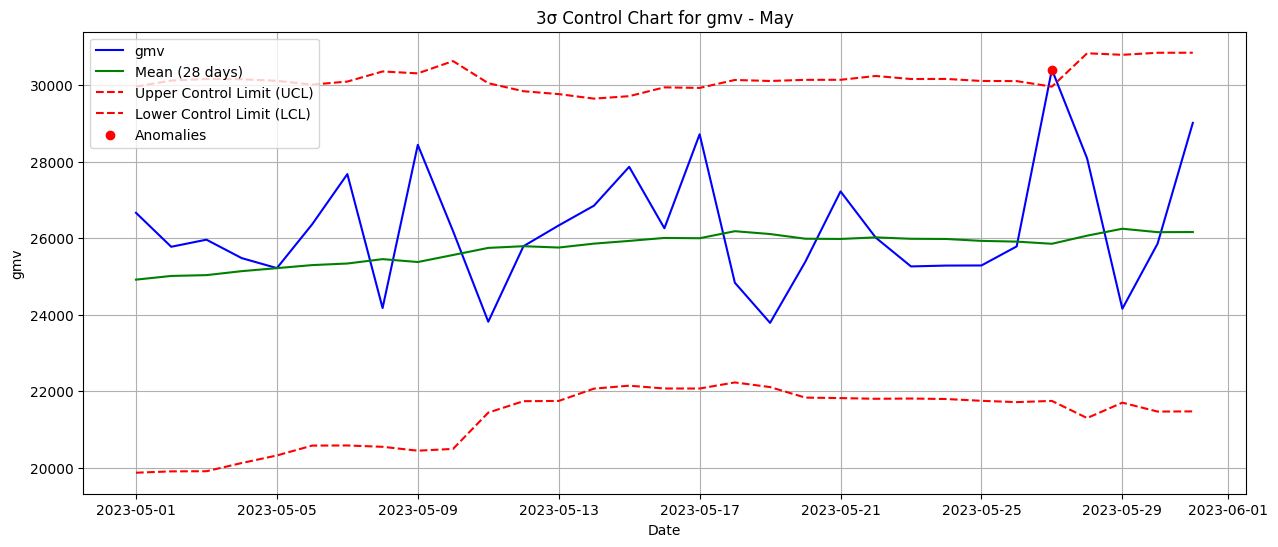

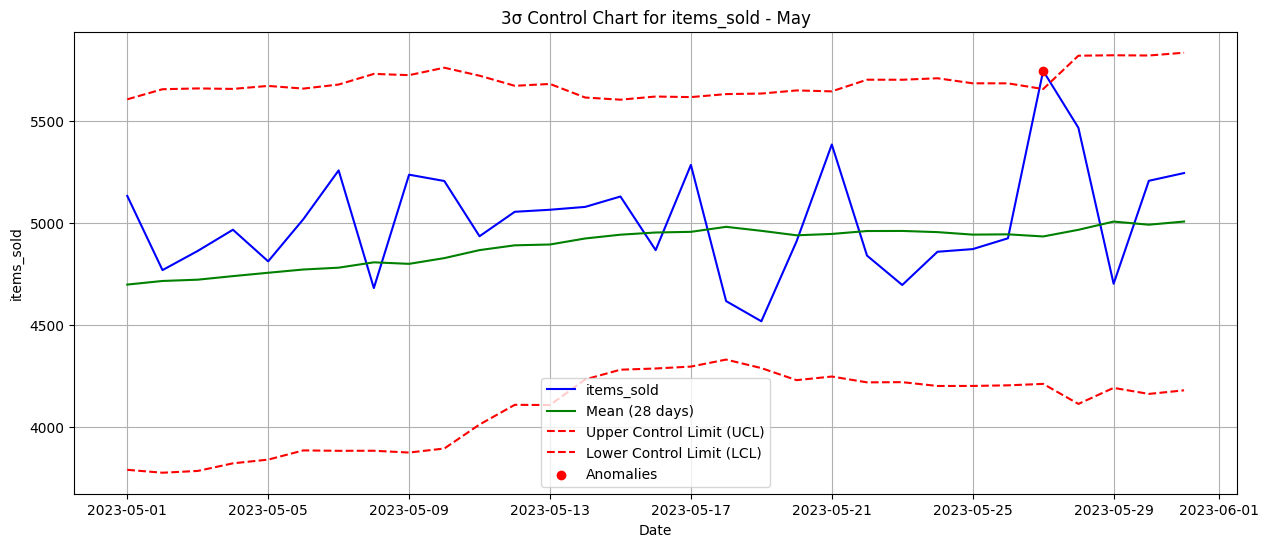

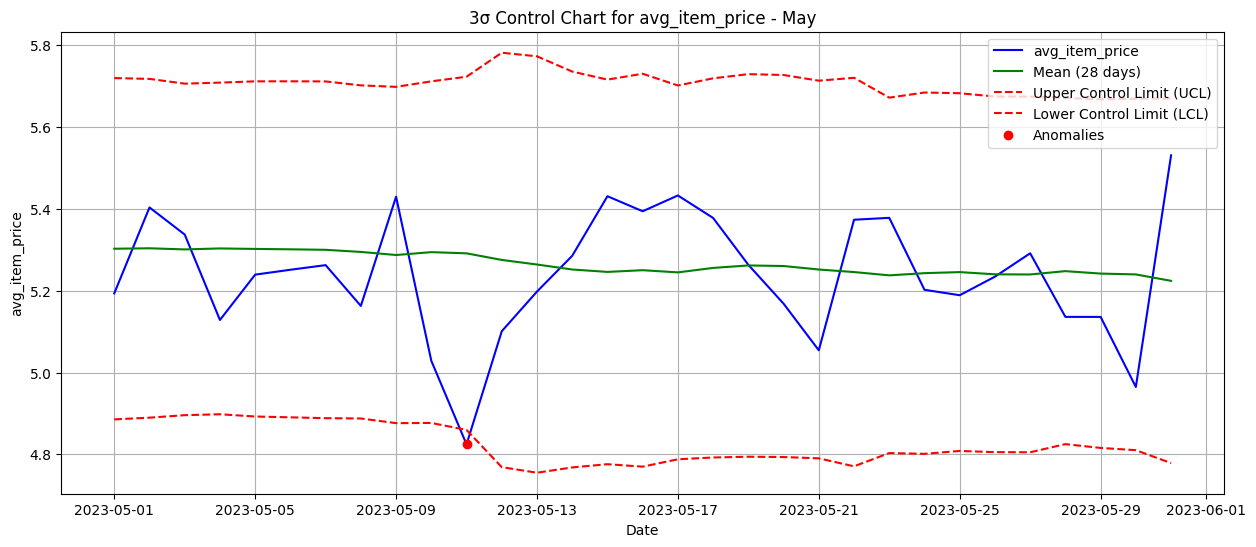

In [5]:
def get_3_sigma_cl(df, metric, window=28, sigma=3):
    df[f'{metric}_mean'] = df[metric].shift(1).rolling(window=window, min_periods=window).mean()
    df[f'{metric}_std'] = df[metric].shift(1).rolling(window=window, min_periods=window).std(ddof=1)

    df[f'{metric}_ucl'] = df[f'{metric}_mean'] + sigma * df[f'{metric}_std']
    df[f'{metric}_lcl'] = df[f'{metric}_mean'] - sigma * df[f'{metric}_std']

    df[f'is_anomaly_{metric}'] = (df[metric] < df[f'{metric}_lcl']) | (df[metric] > df[f'{metric}_ucl'])
    return df

def visualization_3_sigma(df_viz_sigma, metric):

  plt.figure(figsize=(15, 6))
  plt.plot(df_viz_sigma['date'], df_viz_sigma[metric], label=metric, color='blue')
  plt.plot(df_viz_sigma['date'], df_viz_sigma[f'{metric}_mean'], label='Mean (28 days)', color='green')
  plt.plot(df_viz_sigma['date'], df_viz_sigma[f'{metric}_ucl'], label='Upper Control Limit (UCL)', color='red', linestyle='--')
  plt.plot(df_viz_sigma['date'], df_viz_sigma[f'{metric}_lcl'], label='Lower Control Limit (LCL)', color='red', linestyle='--')

  anomalies = df_viz_sigma[df_viz_sigma[f'is_anomaly_{metric}']]
  plt.scatter(anomalies['date'], anomalies[metric], color='red', label='Anomalies', zorder=5)

  plt.title(f'3σ Control Chart for {metric} - May')
  plt.xlabel('Date')
  plt.ylabel(metric)
  plt.legend()
  plt.grid(True)
  plt.show()

df = df.sort_values(by = 'date')
df_3_sigma = df.copy()

df_3_sigma = get_3_sigma_cl(df_3_sigma, 'gmv')
df_3_sigma = get_3_sigma_cl(df_3_sigma, 'items_sold')
df_3_sigma = get_3_sigma_cl(df_3_sigma, 'avg_item_price')

df_plot = df_3_sigma[df_3_sigma['date'].dt.month == 5]

visualization_3_sigma(df_plot, 'gmv')
visualization_3_sigma(df_plot, 'items_sold')
visualization_3_sigma(df_plot, 'avg_item_price')

**Задание**: введите число, являющееся аномальным значением метрики items_sold.

In [6]:
print(df_3_sigma[(df_3_sigma['date'].dt.month == 5) & (df_3_sigma['is_anomaly_avg_item_price'] == True)]['avg_item_price'])

130    4.824481
Name: avg_item_price, dtype: float64


#### 3. Дельта-ряды — 2 балла

1) Рассчитайте дельты значений текущего дня с предыдущим для каждой метрики, затем примените к полученным дельтам правило 3σ:
- gmv;
- items_sold;
- avg_item_price.

Расчет производите на всем датасете. В этом пункте вы имитируете онлайн-мониторинг, поэтому проверка проводится для каждой даты, а границы контроля рассчитываются за последние 28 дней до самой даты.

2) Постройте графики: дельты метрики + границы контроля + выделенные аномалии.

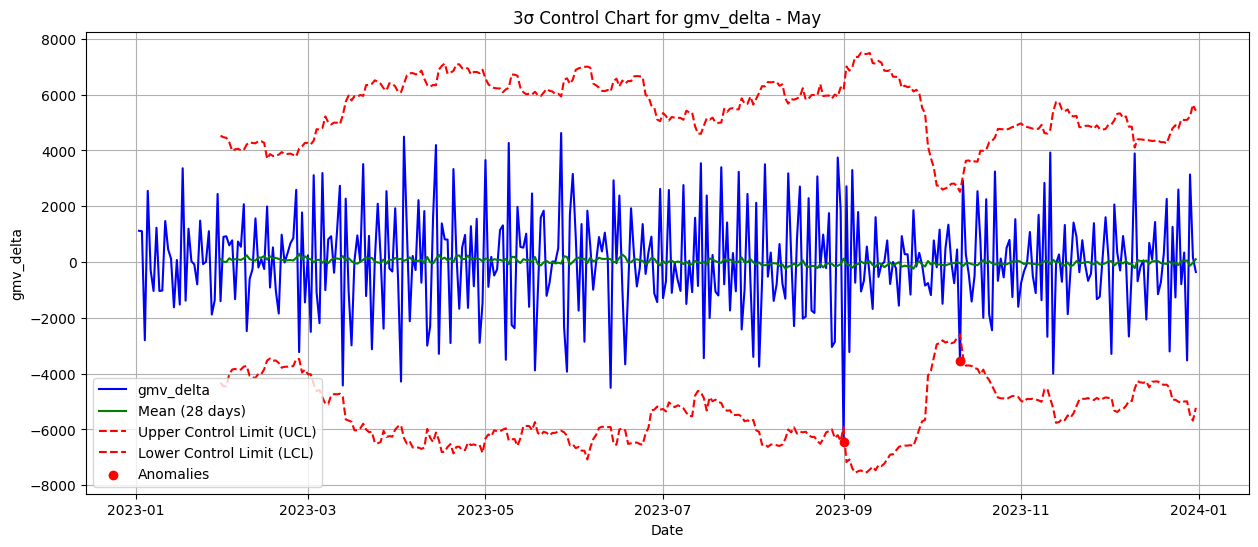

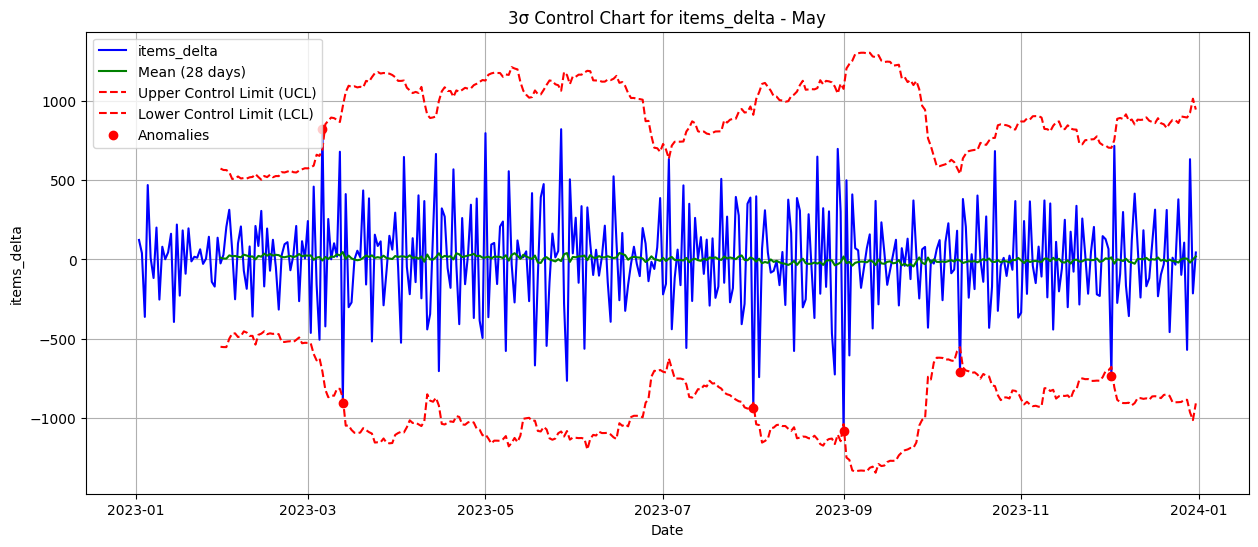

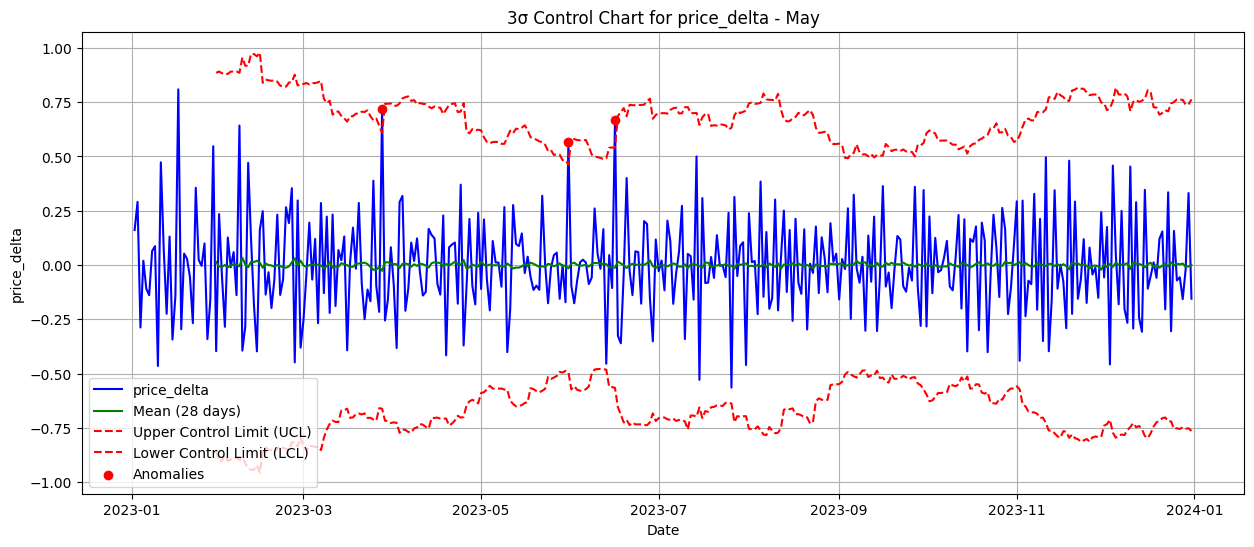

In [7]:
df_delta = df.copy()

df_delta['gmv_delta'] = df['gmv'].diff()
df_delta['items_delta'] = df['items_sold'].diff()
df_delta['price_delta'] = df['avg_item_price'].diff()

df_delta = get_3_sigma_cl(df_delta, 'gmv_delta')
df_delta = get_3_sigma_cl(df_delta, 'items_delta')
df_delta = get_3_sigma_cl(df_delta, 'price_delta')

df_plot = df_delta[df_delta['date'].dt.month == 5]

visualization_3_sigma(df_delta, 'gmv_delta')
visualization_3_sigma(df_delta, 'items_delta')
visualization_3_sigma(df_delta, 'price_delta')

**Задание**: введите аномальное значение дельты avg_item_price, значение округлите до сотых.

In [8]:
print(df_delta[(df_delta['date'].dt.month == 5) & (df_delta['is_anomaly_price_delta'] == True)]['price_delta'])

150    0.566188
Name: price_delta, dtype: float64


#### 4. Generalized ESD — 2 балла

1) Реализуйте [Generalized ESD](https://www.itl.nist.gov/div898/handbook/eda/section3/eda35h3.htm). Обратите внимание, с какими данными работает метод — онлайн или батч? Учтите это в реализации.
2) Найдите аномалии для дельт каждой метрики ЗА МАЙ (используйте данные, полученные на прошлом шаге):
- gmv;
- items_sold;
- avg_item_price.
3) Сравните результаты с правилом 3σ на дельтах: разошлись ли методы?

*Советую обернуть Generalized ESD в функцию, она пригодится на следующем шаге.*

In [9]:
def generalized_esd(df, metric, max_outliers, alpha=0.05):

    data = df[metric].copy().values
    indices = df.index.to_list()
    outliers = []

    for i in range(1, max_outliers + 1):

        mean = data.mean()
        std = data.std(ddof=1)
        deviations = np.abs(data - mean)
        max_deviation_idx = np.argmax(deviations)
        R_i = deviations[max_deviation_idx] / std

        k = len(data)
        p = 1 - alpha / (2 * (k - i + 1))
        t_val = t.ppf(p, k - i - 1)
        lambda_i = ((k - i) * t_val) / np.sqrt((k - i - 1 + t_val**2) * (k - i + 1))

        if R_i > lambda_i:

            outliers.append(indices[max_deviation_idx])
            data = np.delete(data, max_deviation_idx)
            indices.pop(max_deviation_idx)

    return sorted(outliers)

df_esd = df_delta[df_delta['date'].dt.month == 5].copy()
max_outliers = 3
alpha = 0.05

gmv_esd = generalized_esd(df_esd, 'gmv_delta', max_outliers, alpha)
items_esd = generalized_esd(df_esd, 'items_delta', max_outliers, alpha)
price_esd = generalized_esd(df_esd, 'price_delta', max_outliers, alpha)

print(gmv_esd, items_esd, price_esd)
print(df_delta[(df_delta['date'].dt.month == 5) & (df_delta['is_anomaly_gmv_delta'] == True)].index.tolist())
print(df_delta[(df_delta['date'].dt.month == 5) & (df_delta['is_anomaly_items_delta'] == True)].index.tolist())
print(df_delta[(df_delta['date'].dt.month == 5) & (df_delta['is_anomaly_price_delta'] == True)].index.tolist())

[] [] [150]
[]
[]
[150]


**Задание**: для какой даты дельта avg_item_price является аномалией по методу Generalized ESD? Введите дату в фоммате YYYY-MM-DD

In [10]:
for i in range(len(price_esd)):
  print(datetime.date(df_esd.loc[price_esd[i]]['date']))

2023-05-31


#### 5. STL-разложение — 2 балла

1) Для каждой метрики выполните STL-разложение с недельной сезонностью (7 дней) на данных всего датасета:
- gmv;
- items_sold;
- avg_item_price.

Используйте STL из библиотеки statsmodels (уже есть в импортах).
  
2) Для каждой метрики визуализируйте компоненты: тренд, сезонность, остатки (на всем датасете).

4) На остатках примените Generalized ESD, можете использовать функцию из прошлого шага. Это упражнение проделываем только на данных ЗА МАЙ.

5) Подумайте, для каждой ли метрики имеет смысл использовать STL, везде ли визуально присутствуют тренд и недельная сезонность?

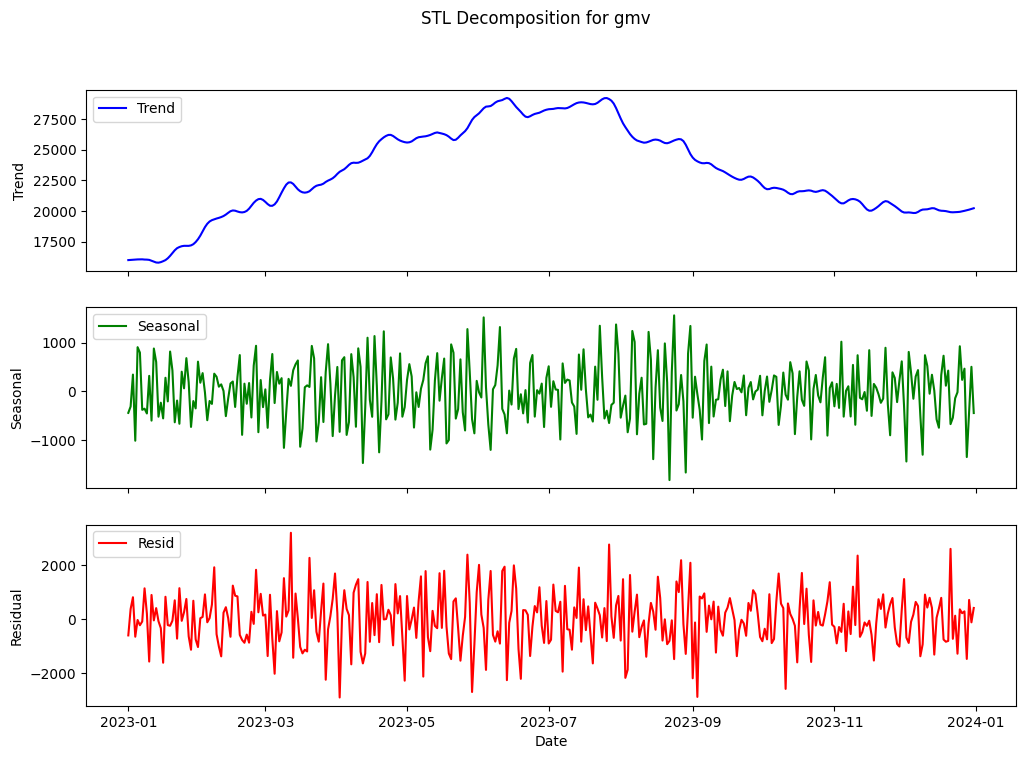

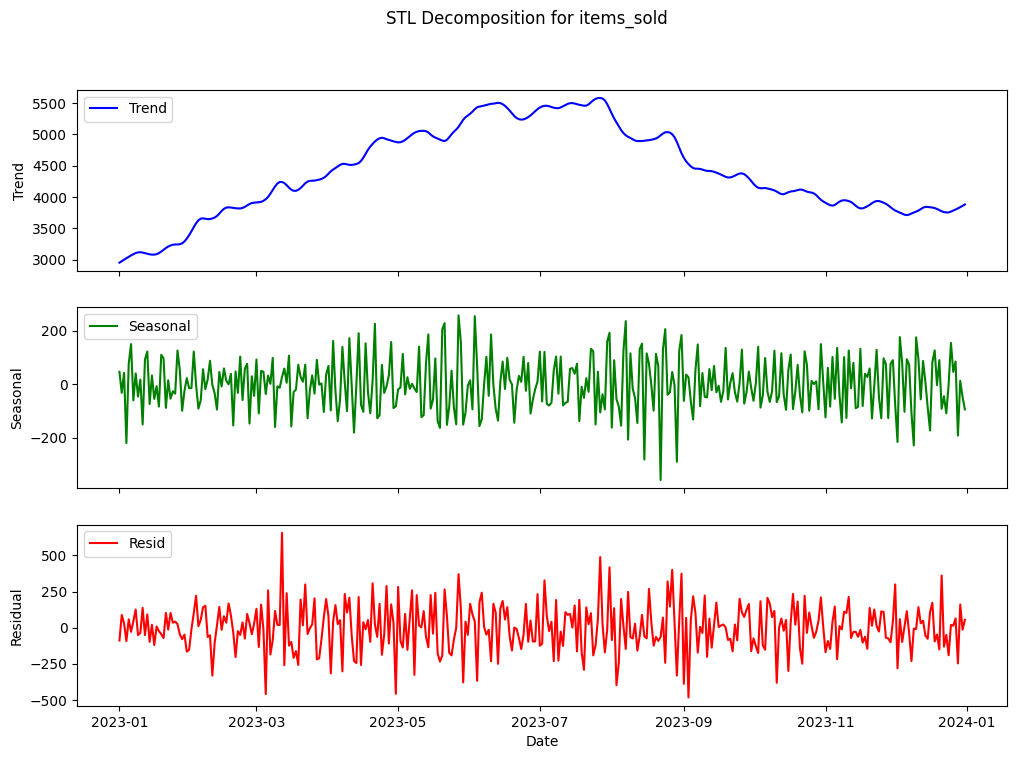

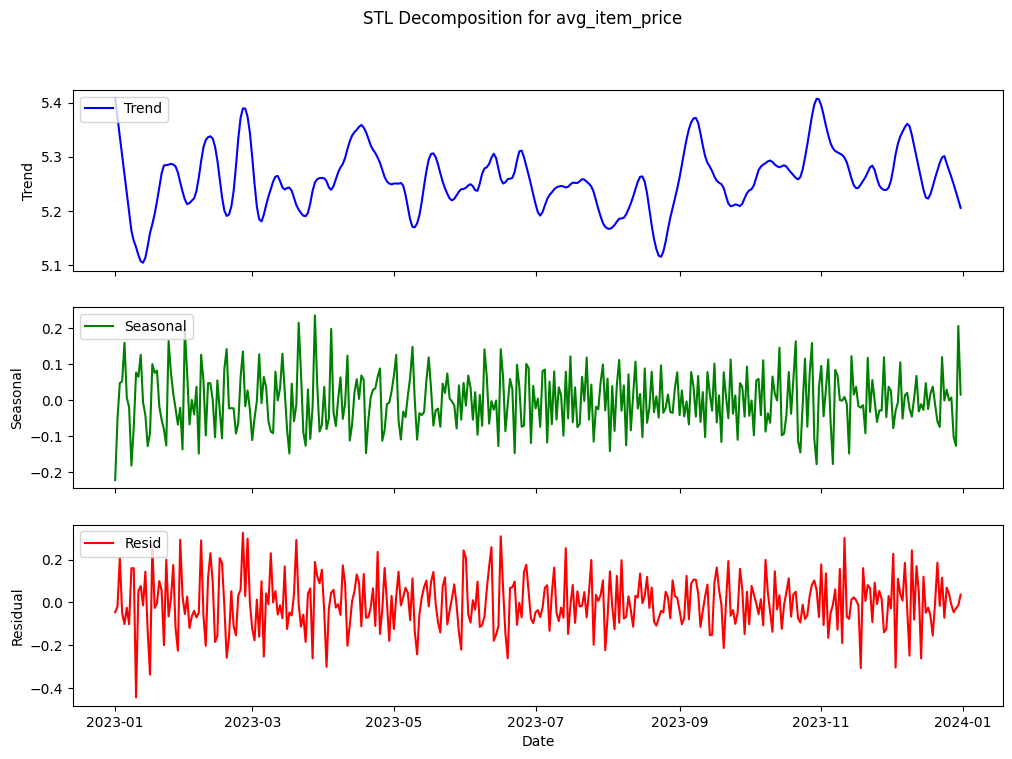

In [11]:
def get_stl_results(df, x, metric, period=7):

  ts = df.set_index(x)[metric]
  stl = STL(ts, period=period)
  stl_results = stl.fit()

  return stl_results

def stl_visualization(stl_result, metric):

  trend = stl_result.trend
  seasonal = stl_result.seasonal
  resid = stl_result.resid

  fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
  fig.suptitle(f'STL Decomposition for {metric}')

  axes[0].plot(trend, label='Trend', color='blue')
  axes[0].legend(loc='upper left')
  axes[0].set_ylabel('Trend')

  axes[1].plot(seasonal, label='Seasonal', color='green')
  axes[1].legend(loc='upper left')
  axes[1].set_ylabel('Seasonal')

  axes[2].plot(resid, label='Resid', color='red')
  axes[2].legend(loc='upper left')
  axes[2].set_ylabel('Residual')
  axes[2].set_xlabel('Date')

  plt.show()

df_stl = df.copy()

stl_visualization(get_stl_results(df_stl, 'date', 'gmv'), 'gmv')
stl_visualization(get_stl_results(df_stl, 'date', 'items_sold'), 'items_sold')
stl_visualization(get_stl_results(df_stl, 'date', 'avg_item_price'), 'avg_item_price')

In [12]:
df_resid = df[df['date'].dt.month == 5].copy()

df_resid['gmv_resid'] = get_stl_results(df_resid, 'date', 'gmv').resid
df_resid['items_resid'] = get_stl_results(df_resid, 'date', 'items_sold').resid
df_resid['price_resid'] = get_stl_results(df_resid, 'date', 'avg_item_price').resid

gmv_resid_esd = generalized_esd(df_resid, 'gmv_resid', max_outliers, alpha)
items_resid_esd = generalized_esd(df_resid, 'items_resid', max_outliers, alpha)
price_resid_esd = generalized_esd(df_resid, 'price_resid', max_outliers, alpha)

print(len(gmv_resid_esd) + len(items_resid_esd) + len(price_resid_esd))

0


**Задание**: введите количество аномалий (сумма для всех метрик — целое число), полученное на остатках STL разложением и Generalized ESD.

4) Подумайте, для каждой ли метрики имеет смысл использовать STL, везде ли визуально присутствуют тренд и недельная сезонность? - тренд не прослеживается ни в одной метрике, а сезонность - да. В связи с этим имеет смысл использовать STL, поскольку он сможет выделить сезонную компоненту

#### 6. EWMA — 2 балла

1) Реализуйте метод [EWMA](https://www.itl.nist.gov/div898/handbook/pmc/section3/pmc324.htm) для каждой метрики:
- gmv;
- items_sold;
- avg_item_price.

При расчётах используйте экспоненциальное сглаживание λ = 0.2, доверительные границы μ ± L·σ, где L = 3. Стандартное отклонение вычисляйте на окне 28 дней и используйте функцию асимптотического приближения:

$$
\sigma_z(\infty) = \sigma \sqrt{\frac{\lambda}{2-\lambda}}
$$

Обратите внимание, что в pandas есть [встроенная функция экспоненциального сглаживания](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.ewm.html).


2) Постройте графики: сглаженная метрика + границы контроля + выделенные аномалии.
3) Напишите, какой из подходов вам больше всего понравился для онлайн-мониторинга, а какой — для ретроспективного анализа, и почему. Тут нет правильного ответа :)

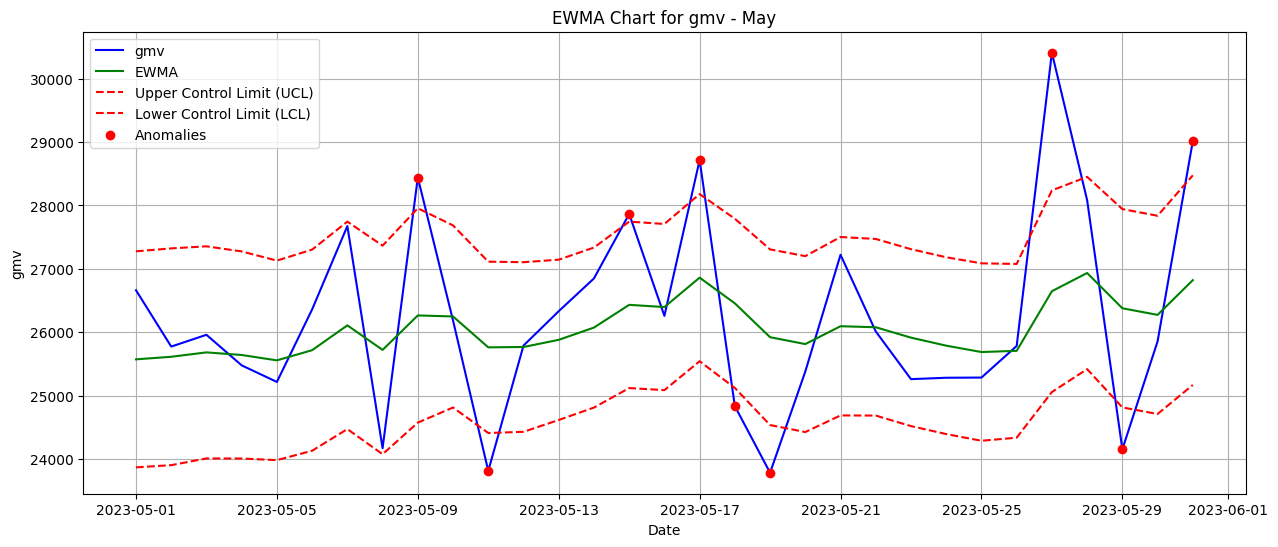

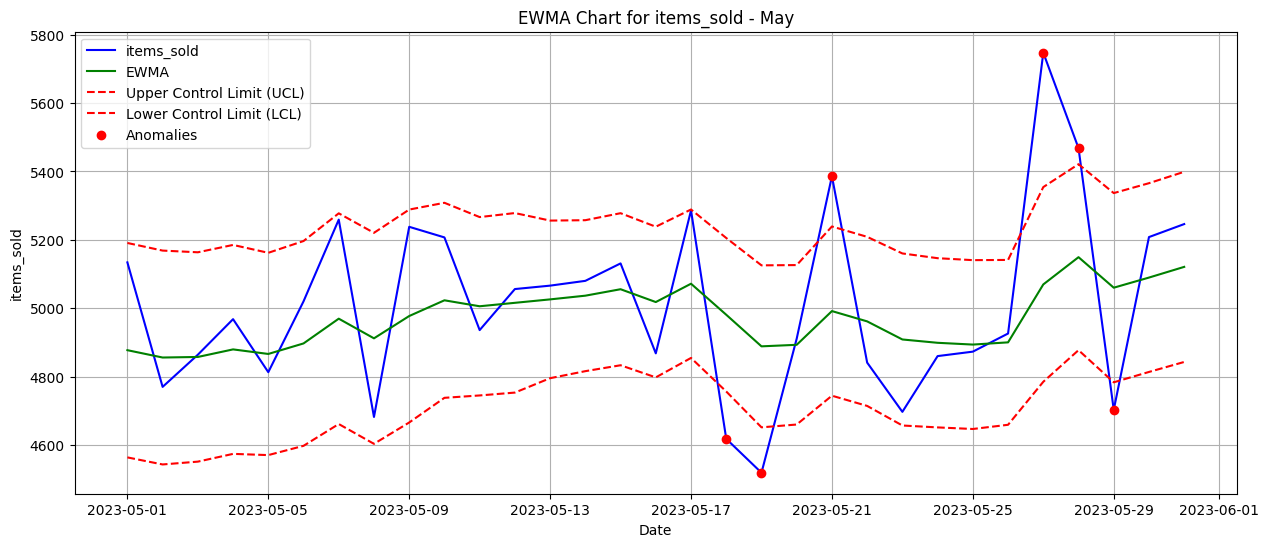

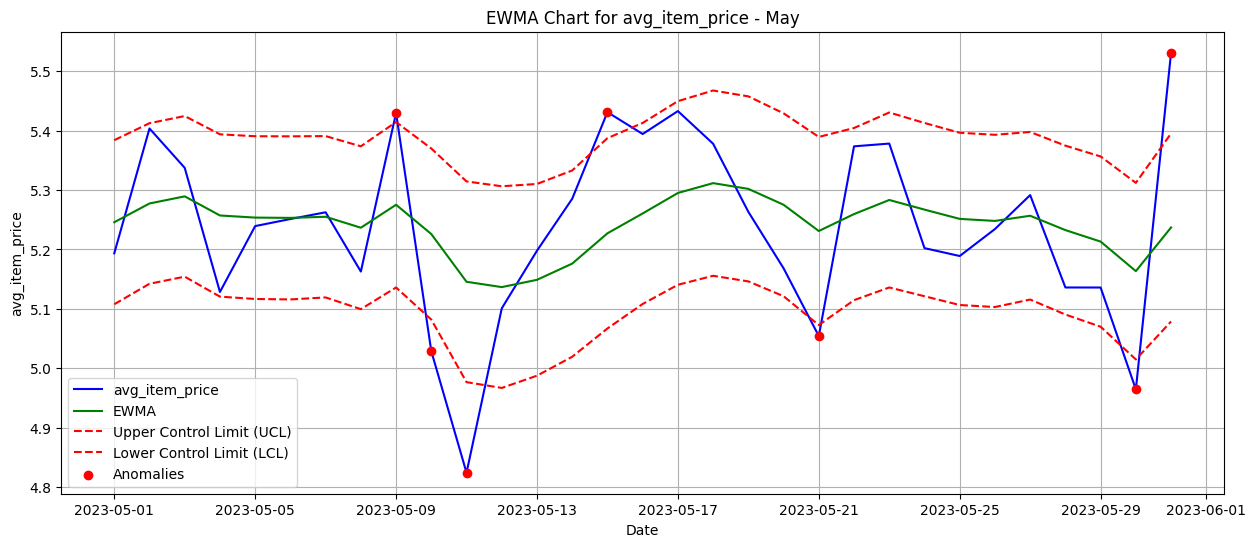

In [13]:
def get_ewma_control(df, metric, lambda_param=0.2, L=3, window=28):

    df[f'{metric}_ewma'] = df[metric].ewm(alpha=lambda_param).mean()
    df[f'{metric}_std'] = df[metric].rolling(window=window, min_periods=1).std()

    sigma_z = df[f'{metric}_std'] * np.sqrt(lambda_param / (2 - lambda_param))

    df[f'{metric}_ucl'] = df[f'{metric}_ewma'] + L * sigma_z
    df[f'{metric}_lcl'] = df[f'{metric}_ewma'] - L * sigma_z

    df[f'is_anomaly_{metric}'] = (df[metric] > df[f'{metric}_ucl']) | (df[metric] < df[f'{metric}_lcl'])

    return df

def visualization_ewma(df_viz, metric):

  plt.figure(figsize=(15, 6))
  plt.plot(df_viz['date'], df_viz[metric], label=metric, color='blue')
  plt.plot(df_viz['date'], df_viz[f'{metric}_ewma'], label='EWMA', color='green')
  plt.plot(df_viz['date'], df_viz[f'{metric}_ucl'], label='Upper Control Limit (UCL)', color='red', linestyle='--')
  plt.plot(df_viz['date'], df_viz[f'{metric}_lcl'], label='Lower Control Limit (LCL)', color='red', linestyle='--')

  anomalies = df_viz[df_viz[f'is_anomaly_{metric}']]
  plt.scatter(anomalies['date'], anomalies[metric], color='red', label='Anomalies', zorder=5)

  plt.title(f'EWMA Chart for {metric} - May')
  plt.xlabel('Date')
  plt.ylabel(metric)
  plt.legend()
  plt.grid(True)
  plt.show()

df_ewma = df.copy()

df_ewma = get_ewma_control(df_ewma, 'gmv')
df_ewma = get_ewma_control(df_ewma, 'items_sold')
df_ewma = get_ewma_control(df_ewma, 'avg_item_price')

df_plot_ewma = df_ewma[df_ewma['date'].dt.month == 5]

visualization_ewma(df_plot_ewma, 'gmv')
visualization_ewma(df_plot_ewma, 'items_sold')
visualization_ewma(df_plot_ewma, 'avg_item_price')

**Задание**: введите сглаженное значение метрики avg_item_price, являющееся аномальным по методу EWMA. Ответ округлите до сотых.

In [14]:
round(df_plot_ewma[df_plot_ewma['is_anomaly_avg_item_price'] == True]['avg_item_price_ewma'], 2)

,avg_item_price_ewma
128,5.28
129,5.23
130,5.15
134,5.23
140,5.23
149,5.16
150,5.24


Из всех методов мне очень понравились правило 3 сигм и EWMA, они легки в реализации, а их значения для меня лично наиболее просты в понимании